# UVMOS ETC Example for Generating M star Spectra (Flaring and Quiescence)

_Written by Jocelyn Roney - June 2026_

This notebook shows two examples using the UVMOS ETC `M_star_spectra` function with the first example modelling the M star in quiescence and the second modelling stellar flaring. This function was created to more accurately model M stars as previous models underestimate the UV radiation being emitted.

Both examples will model the M star EV Lacertae. This star is one of five that has been selected to undergo 24 hours of spectroscopic monitoring in CASTORs *Legacy* survey, _'Assessing the Impact of M Star UV Radiation Environments on Planetary Atmospheres'_. The user will input the stars parameters into the function which will return a spectrum. The spectrum can then be directly inputted into the UVMOS ETC for Signal-to-Noise Ratio (SNR) calculations. The Mg II doublet will be used for spectroscopy as it is a distinct tracer of stellar magnetic activity.

For more information on this function and how it was created go to -> ETC/castor_etc/spectra/models/flare.py

Note: This notebook doesn't use the multi-slit function as it is is only for one point source.

## First Import CASTOR Packages

In [4]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from castor_etc.background import Background
from castor_etc.photometry import Photometry
from castor_etc.sources import ExtendedSource, GalaxySource, PointSource
from castor_etc.telescope import Telescope
from castor_etc.uvmos_spectroscopy import UVMOS_Spectroscopy

# Specify the telescope parameters by creating a Telescope and Background objects. 
MyTelescope = Telescope()
MyTelescope = Telescope(read_noise=2.0)
MyBackground = Background()

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST


# M Star Quiescent Exmple
## Simulate the Source: Create the Spectrum

In the `M_star_spectra` function, input the radius in solar masses, the temperature in Kelvin, and the distance in kpc. Then type yes or no to add a flare and show the spectrum. EV Lacertae has a radius of 0.353 solar masses, temperature of 3270 K, and a distance of 0.005049 kpc from Earth. 


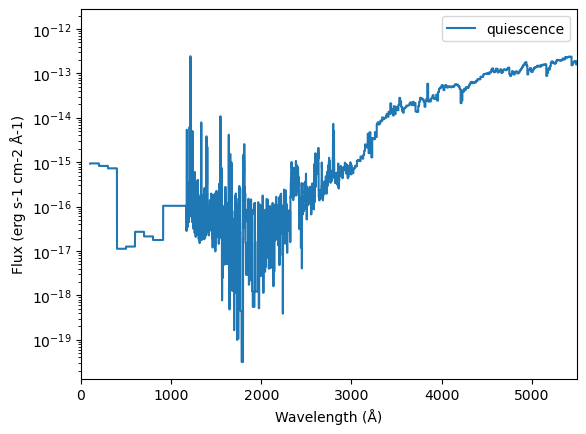

In [16]:
#This function will return a tuple
# M_star_quiet_EV_Lac[0] is the wavelength in a numpy.ndarray
# M_star_quiet_EV_Lac[1] is the flux in a numpy.ndarray

M_star_quiet_EV_Lac = M_star_spectra(0.353, 3270, 0.005049, add_flare = 'no', show_figure = 'yes')

## Do Spectroscopy

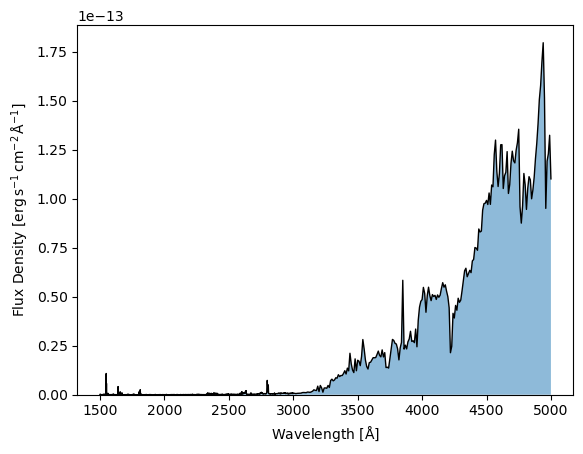

In [17]:
MySource = PointSource()
MySource.set_spectrum(wavelengths = M_star_quiet_EV_Lac[0], spectrum = M_star_quiet_EV_Lac[1], unit = "flam")
MySource.show_spectrum()

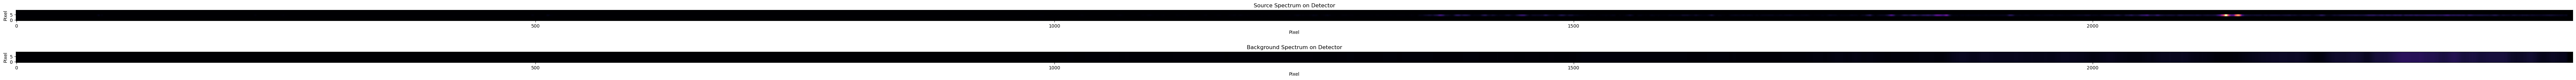

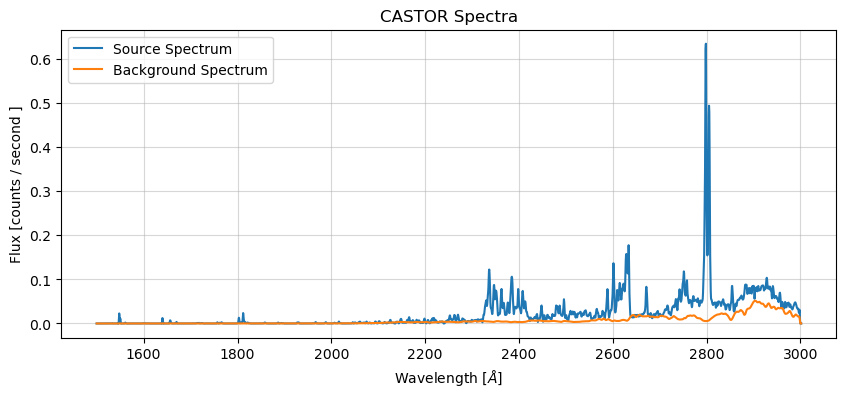

In [18]:
#Create Spectroscopy object
MySpec = UVMOS_Spectroscopy(MyTelescope, MySource, MyBackground)

# Optional: You can change the min and max with the functions below
#MySpec.min_wave = (150 * u.nm).to(u.AA)
#MySpec.max_wave = (300 * u.nm).to(u.AA)

# Specify the slit
MySpec.specify_slit()
#You can change the height and width of the slit with the function below
#MySpec.specify_slit(slit_width = 0.15 * u.arcsec, slit_height = 0.5 * u.arcsec)


# Optional: Show the source as viewed through the slit
#MySpec.show_slit()

# Optional: Show a single image of the slit on the detector
#MySpec.show_source_pix_weights()



MySpec.calc_source_CASTORSpectrum(extraction_width=1, extraction_lowerlim=1, extraction_upperlim = 'max')
MySpec.calc_background_CASTORSpectrum(extraction_width=1, extraction_lowerlim=1, extraction_upperlim = 'max')

#
# Optional: Visualize the source and background spectra on the detector
#

plt.figure(figsize=(100,3))

ax1 = plt.subplot(211)
plt.imshow(MySpec.source_detector,origin='lower',cmap='magma',aspect='auto')
plt.title('Source Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax1.set_aspect('equal')


ax2 = plt.subplot(212, sharex=ax1, sharey=ax1)
plt.imshow(MySpec.background_detector*MySpec.source_extracted_numpixs,origin='lower',cmap='magma',aspect='auto', vmin=min(MySpec.source_detector.flatten()), vmax=max(MySpec.source_detector.flatten()))
plt.title('Background Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax2.set_aspect('equal')

#
# Optional: Visualize the source and background 
#
plt.figure(figsize=(10,4))

ax = plt.subplot(111)
plt.plot(MySpec.waves_CASTORSpectrum, MySpec.source_CASTORSpectrum,'-',label='Source Spectrum')

plt.plot(MySpec.waves_CASTORSpectrum, MySpec.background_CASTORSpectrum*MySpec.source_extracted_numpixs,'-',label='Background Spectrum')

plt.title('CASTOR Spectra')
plt.xlabel('Wavelength '+r'[$\AA$]')
plt.ylabel('Flux [counts / second ]')
plt.grid(alpha=0.5)
plt.legend()

**Determine Exposure time for Mg II k or 2803.53 Angstrom**

The very large peak/emission line in the CASTOR spectrum is Mg II k and h.

In [19]:
snr = 10  
wave = 2803.53 # angstroms
t = MySpec.calc_t_from_snr(snr, wave)

print('An exposure time of {:.3g} seconds or {:.1f} hours is required to reach a SNR of {:.3f} at a wavelength of {} angstroms'.format(t, t/3600, snr, wave))

An exposure time of 1.11e+04 seconds or 3.1 hours is required to reach a SNR of 10.000 at a wavelength of 2803.53 angstroms


# *Repeat for Flaring Phase and Compare*

## Simulate the Source: Flaring Phase

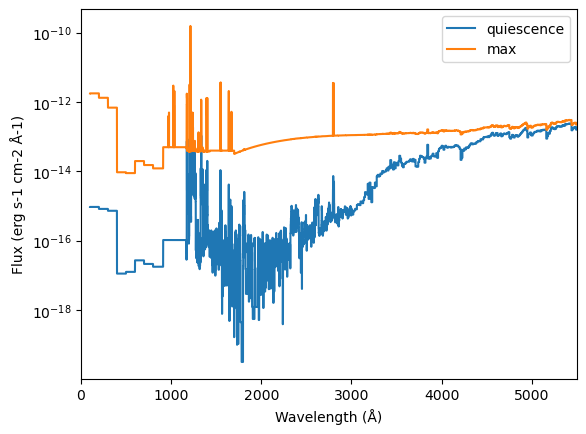

In [10]:
M_star_flare_EV_Lac = M_star_spectra(0.353, 3270, 0.005049, add_flare = 'yes', show_figure = 'yes')

## Do Spectroscopy

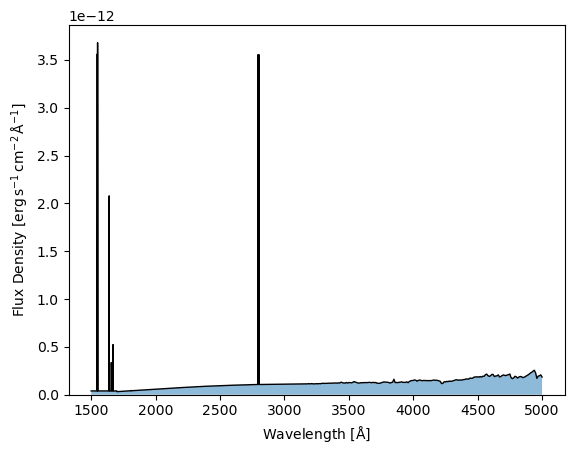

In [11]:
MySource = PointSource()
MySource.set_spectrum(wavelengths = M_star_flare_EV_Lac[0], spectrum = M_star_flare_EV_Lac[1], unit = "flam")
MySource.show_spectrum()

#Create Spectroscopy object
MySpec = UVMOS_Spectroscopy(MyTelescope, MySource, MyBackground)

# Specify the slit
MySpec.specify_slit()

# Optional: Show the source as viewed through the slit
# MySpec.show_slit()

# Optional: Show a single image of the slit on the detector
# MySpec.show_source_pix_weights()

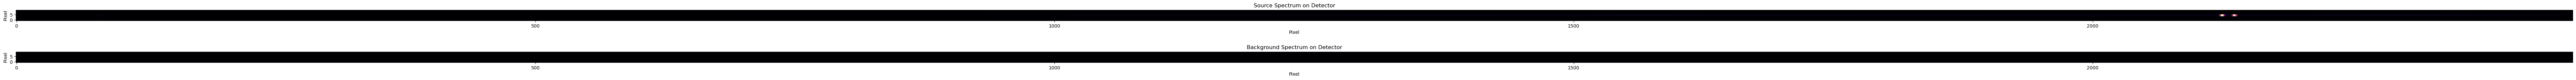

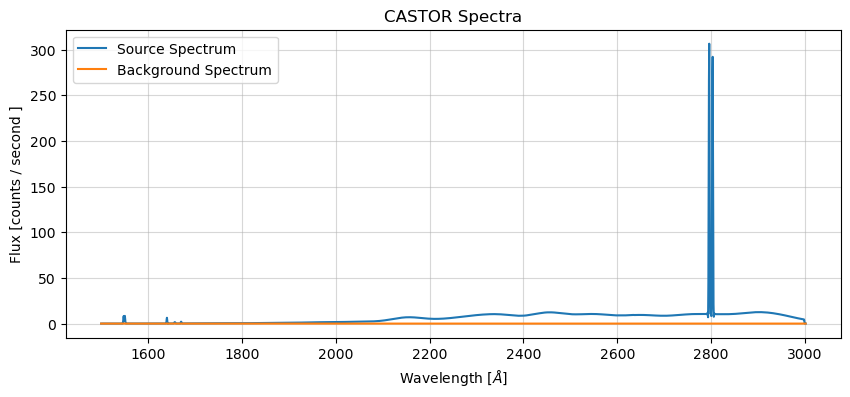

In [12]:
MySpec.calc_source_CASTORSpectrum(extraction_width=1, extraction_lowerlim=1, extraction_upperlim = 'max')
MySpec.calc_background_CASTORSpectrum(extraction_width=1, extraction_lowerlim=1, extraction_upperlim = 'max')

# Optional: Visualize the source and background spectra on the detector
plt.figure(figsize=(100,3))

ax1 = plt.subplot(211)
plt.imshow(MySpec.source_detector,origin='lower',cmap='magma',aspect='auto')
plt.title('Source Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax1.set_aspect('equal')


ax2 = plt.subplot(212, sharex=ax1, sharey=ax1)
plt.imshow(MySpec.background_detector*MySpec.source_extracted_numpixs,origin='lower',cmap='magma',aspect='auto', vmin=min(MySpec.source_detector.flatten()), vmax=max(MySpec.source_detector.flatten()))
plt.title('Background Spectrum on Detector')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
ax2.set_aspect('equal')

# Optional: Visualize the source and background 
plt.figure(figsize=(10,4))
ax = plt.subplot(111)
plt.plot(MySpec.waves_CASTORSpectrum, MySpec.source_CASTORSpectrum,'-',label='Source Spectrum')

plt.plot(MySpec.waves_CASTORSpectrum, MySpec.background_CASTORSpectrum*MySpec.source_extracted_numpixs,'-',label='Background Spectrum')

plt.title('CASTOR Spectra')
plt.xlabel('Wavelength '+r'[$\AA$]')
plt.ylabel('Flux [counts / second ]')
plt.grid(alpha=0.5)
plt.legend()

**Determine Exposure time for Mg II k or 2803.53 Angstrom**

This CASTOR spectrum has far less visible emission and absorbtion lines, only Mg II. This is due to the rapid magnetic energy release during a flare making the element much brighter and stronger than the rest.

In [14]:
snr = 20
wave = 2803.53 # angstroms
t = MySpec.calc_t_from_snr(snr, wave)
t = t.astype(float)
print('An exposure time of {:.3g} seconds or {:.3g} hours is required to reach a SNR of {:.3f} at a wavelength of {} angstroms'.format(t, t/3600, snr, wave))

An exposure time of 24.2 seconds or 0.00673 hours is required to reach a SNR of 20.000 at a wavelength of 2803.53 angstroms


In [15]:
snr = 50
wave = 2803.53 # angstroms
t = MySpec.calc_t_from_snr(snr, wave)
t = t.astype(float)
print('An exposure time of {:.3g} seconds or {:.3g} hours is required to reach a SNR of {:.3f} at a wavelength of {} angstroms'.format(t, (t/3600), snr, wave))

An exposure time of 63.4 seconds or 0.0176 hours is required to reach a SNR of 50.000 at a wavelength of 2803.53 angstroms


When comparing quiescent phase to flaring phase we can see a drastically different SNR and CASTOR spectra. Flares can make M stars 10x to 1000x brighter depending on the flare energy which we can see when comparing the two phases SNR times (hours for quiescence and seconds for flaring).